In [1]:
# 1. 한글 폰트 설치 (실행 후 '런타임 다시 시작'이 필요할 수 있습니다)
!sudo apt-get install -y fonts-nanum
!google-感动-fc-cache -fv
!rm ~/.cache/matplotlib -rf

import pandas as pd # 데이터 분석을 위한 라이브러리
import matplotlib.pyplot as plt # 시각화를 위한 라이브러리
import seaborn as sns # 더 예쁜 그래프를 위한 라이브러리

# 2. 한글 폰트 설정
plt.rc('font', family='NanumBarunGothic')

# 3. 데이터 불러오기 (파일명이 다르면 수정해 주세요)
orders = pd.read_csv('ShopEasy_Order_Data_1000.csv') # 주문 데이터 로드
users = pd.read_csv('ShopEasy_User_Data_500.csv') # 유저 데이터 로드
sessions = pd.read_csv('ShopEasy_Session_Data_2000.csv') # 세션 데이터 로드

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 6 not upgraded.
/bin/bash: line 1: google-感动-fc-cache: command not found


--- 연령대별 이탈률 표 ---
  age_group  bounce_rate_%
0       20대       3.225806
1       30대       1.449275
2       40대       1.769912
3    50대 이상       2.400000


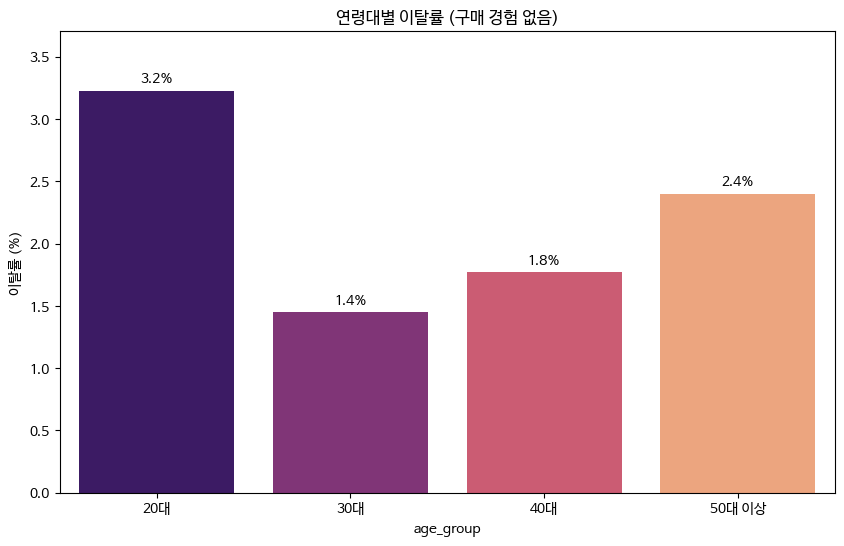

In [11]:
# 구매 횟수가 0인 유저를 구분하는 컬럼 생성
users['is_bounced'] = users['purchase_count'] == 0 # 구매횟수가 0이면 True, 아니면 False

# 연령대별로 이탈 여부의 평균을 구함 (True는 1, False는 0으로 계산되어 바로 비율이 됨)
age_bounce_rate = users.groupby('age_group')['is_bounced'].mean().reset_index() # 연령대별 평균 계산
age_bounce_rate['bounce_rate_%'] = age_bounce_rate['is_bounced'] * 100 # 소수를 백분율로 변환

print("--- 연령대별 이탈률 표 ---")
print(age_bounce_rate[['age_group', 'bounce_rate_%']]) # 결과 표 출력

# 시각화
plt.figure(figsize=(10, 6))

# 막대 그래프 생성(ax 변수에 담기)
ax = sns.barplot(x='age_group', y='bounce_rate_%', data=age_bounce_rate,
                 palette='magma', hue='age_group', legend=False)

# for 반복문으로 모든 막대에 수치 표시
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title('연령대별 이탈률 (구매 경험 없음)')
plt.ylabel('이탈률 (%)')

# 숫자가 위쪽에 잘리지 않게 y축 상단에 15% 정도 여유 부여
plt.ylim(0, age_bounce_rate['bounce_rate_%'].max() * 1.15)
plt.show()

--- 카테고리별 주문 완료율 표 ---
order_status category  completion_rate_%
0                  뷰티          67.317073
1                  식품          68.627451
2                전자기기          61.165049
3                  패션          67.839196
4                 홈리빙          72.043011


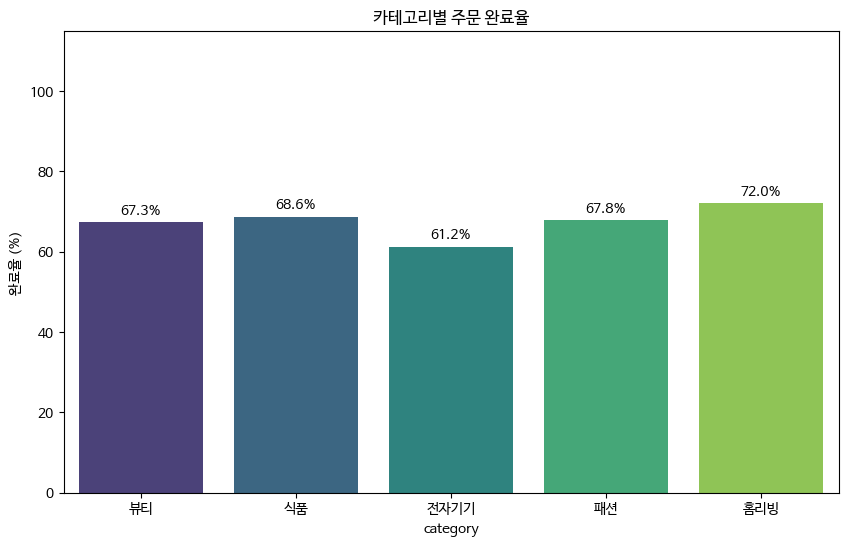

In [13]:
# 카테고리별 주문 상태 개수 계산
category_status = orders.groupby(['category', 'order_status']).size().unstack(fill_value=0) # 상태별 카운트 표 생성

# 완료율 계산 (완료 건수 / 전체 건수)
category_status['completion_rate_%'] = (category_status['완료'] / category_status.sum(axis=1)) * 100 # 완료율 컬럼 추가
category_status_final = category_status.reset_index() # 인덱스 초기화

print("--- 카테고리별 주문 완료율 표 ---")
print(category_status_final[['category', 'completion_rate_%']]) # 결과 표 출력

# 시각화
plt.figure(figsize=(10, 6))

# 1. 막대 그래프 생성 (ax 변수에 담기)
ax = sns.barplot(x='category', y='completion_rate_%', data=category_status_final,
                 palette='viridis', hue='category', legend=False)

# 2. 반복문을 사용하여 모든 막대에 수치 표시
# fmt='%.1f%%' : 소수점 첫째 자리까지 표시하고 뒤에 % 기호를 붙임
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title('카테고리별 주문 완료율') # 제목 설정
plt.ylabel('완료율 (%)') # y축 라벨 설정
plt.ylim(0, 115) # 수치가 그래프 천장에 붙지 않도록 여유 공간 확보 (0~115)
plt.show()

--- 진입 페이지별 분석 표 ---
  entry_page  session_duration  conversion_rate_%
0         검색        310.288136          19.915254
1       상품상세        303.913793          20.689655
2       카테고리        296.346154          23.684211
3          홈        309.021484          18.164062


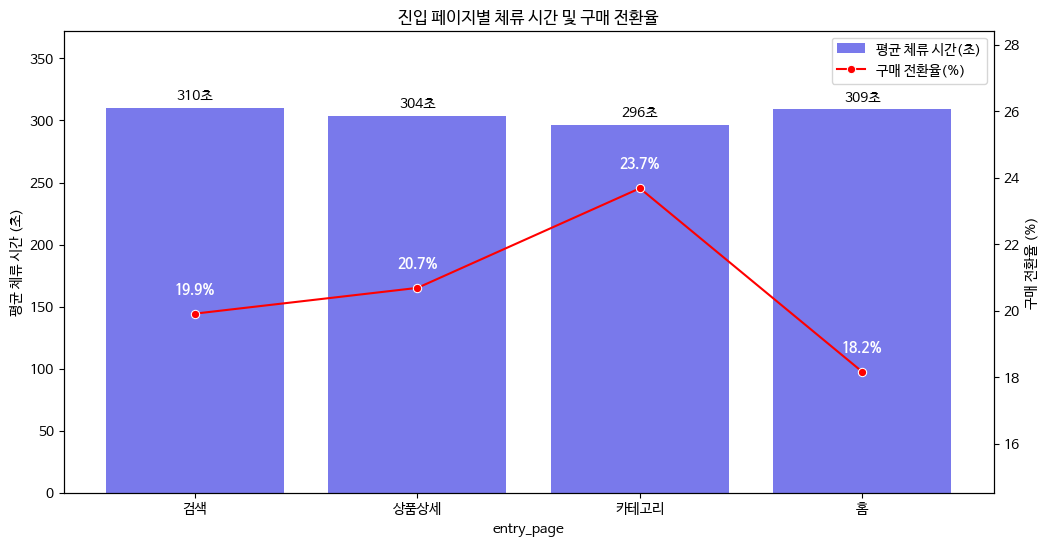

In [16]:
# 구매 전환 여부 컬럼 생성 (이탈 페이지가 '완료'이면 구매로 간주)
sessions['is_converted'] = sessions['exit_page'] == '완료' # 전환 여부 판단

# 진입 페이지별로 세션 시간 평균과 전환율(평균) 계산
session_analysis = sessions.groupby('entry_page').agg({
    'session_duration': 'mean', # 체류 시간 평균
    'is_converted': 'mean' # 전환율 평균
}).reset_index()

session_analysis['conversion_rate_%'] = session_analysis['is_converted'] * 100 # 백분율 변환

print("--- 진입 페이지별 분석 표 ---")
print(session_analysis[['entry_page', 'session_duration', 'conversion_rate_%']]) # 결과 표 출력

# 시각화
fig, ax1 = plt.subplots(figsize=(12, 6))

# 1. 평균 체류 시간 (막대 그래프)
ax = sns.barplot(x='entry_page', y='session_duration', data=session_analysis,
                 ax=ax1, alpha=0.6, color='blue', label='평균 체류 시간(초)')
ax1.set_ylabel('평균 체류 시간 (초)')

# 막대 그래프 위에 수치 표시 (단위: 초)
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.0f초', padding=3)

# 2. 구매 전환율 (선 그래프)
ax2 = ax1.twinx()
sns.lineplot(x='entry_page', y='conversion_rate_%', data=session_analysis,
             ax=ax2, marker='o', color='red', label='구매 전환율(%)')
ax2.set_ylabel('구매 전환율 (%)')

# 선 그래프의 점 위에 수치 표시 (단위: %)
# x축의 위치(i)와 전환율 값(val)을 하나씩 가져와서 텍스트로 사용
for i, val in enumerate(session_analysis['conversion_rate_%']):
    ax2.text(i, val + 0.5, f'{val:.1f}%', color='white',
             ha='center', va='bottom', fontweight='bold')

# 3. 범례 합치기 및 위치 조정
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

# 불필요한 중복 범례 제거 및 여유 공간 설정
if ax1.get_legend(): ax1.get_legend().remove()
ax1.set_ylim(0, session_analysis['session_duration'].max() * 1.2)
ax2.set_ylim(session_analysis['conversion_rate_%'].min() * 0.8,
             session_analysis['conversion_rate_%'].max() * 1.2)

plt.title('진입 페이지별 체류 시간 및 구매 전환율')
plt.show()

In [17]:
# '연-월' 추출을 위한 코드
orders['order_month'] = pd.to_datetime(orders['order_date']).dt.to_period('M').astype(str)

# 월별 주문 수 계산 (확인용)
monthly_orders = orders.groupby('order_month').size().reset_index(name='order_count')

print("--- 월별 주문 수 데이터 ---")
print(monthly_orders)

# 대시보드용 파일로 저장
orders.to_csv('ShopEasy_Orders_for_Looker.csv', index=False, encoding='utf-8-sig')

--- 월별 주문 수 데이터 ---
  order_month  order_count
0     2025-07          339
1     2025-08          354
2     2025-09          307
